# Training a GRPO Agent on the Complex Factory

This notebook demonstrates how to train a **Group Relative Policy Optimization
(GRPO)** agent with a Transformer backbone on the complex factory environment.

We will:
1. Set up the complex factory scenario with token-ID observations
2. Run a warmup phase to populate the tokenizer vocabulary
3. Initialize and train the GRPO agent
4. Compare the trained agent against heuristic baselines
5. Visualize training curves and policy behaviour

In [1]:
import os, sys, warnings, logging
from contextlib import contextmanager

logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")
os.environ["KATA_CONF_PATH"] = "/dev/null/no_such_file.json"

@contextmanager
def quiet():
    old = sys.stdout
    sys.stdout = open(os.devnull, "w")
    try:
        yield
    finally:
        sys.stdout.close()
        sys.stdout = old

## 1. Factory configuration

Same complex factory as in `complex_factory.ipynb`, but configured with
`token_ids` observations and a richer reward signal that combines the original
components with five new ones:

| Component | Signal | Why |
|---|---|---|
| `assignment` | +1 per dispatch | Baseline heartbeat |
| `wait_time` | Ticket wait penalty | Encourage fast response |
| `queue_size` | Pending queue penalty | Discourage queue build-up |
| `busy_technician` | Penalty for busy tech | Prefer available technicians |
| **`fatigue_cost`** | Continuous fatigue penalty | Prefer rested technicians (gradient, not cliff) |
| **`knowledge_match`** | Expertise-repair alignment | Core knowledge-aware objective |
| **`workload_balance`** | Fleet fatigue std-dev penalty | Spread work evenly |
| **`estimated_repair_time`** | Log-ratio of estimated vs base repair | Joint knowledge+fatigue quality |
| **`machine_criticality`** | Productivity share + buffer backlog | Prioritise high-value machines |

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from kata.core.config import (
    KATAConfig, GymEnvConfig, GymRewardConfig, RewardComponentConfig,
    TechnicianConfig, MachineConfig, ProductConfig, ComponentConfig,
)
from kata.features.breakdown.config import WeibullBreakdownConfig, SimpleBreakdownConfig
from kata.scenario import ScenarioBuilder
from kata.env import KataEnv

cfg = KATAConfig(
    technicians={
        "expert": TechnicianConfig(
            name="expert",
            fatigue_lambda=0.005,
            fatigue_mu=0.08,
            knowledge_learning_rate=0.15,
        ),
        "generalist": TechnicianConfig(
            name="generalist",
            fatigue_lambda=0.01,
            fatigue_mu=0.05,
            knowledge_learning_rate=0.10,
        ),
        "junior_1": TechnicianConfig(
            name="junior_1",
            fatigue_lambda=0.02,
            fatigue_mu=0.03,
            knowledge_learning_rate=0.05,
        ),
        "junior_2": TechnicianConfig(
            name="junior_2",
            fatigue_lambda=0.02,
            fatigue_mu=0.03,
            knowledge_learning_rate=0.05,
        ),
    },
    machines={
        "cnc_1": MachineConfig(
            machine_type="CNC",
            process_time=200,
            components={
                "spindle": ComponentConfig(
                    component_id="spindle_0", component_type="spindle",
                    base_repair_time=90.0,
                    breakdown_model="weibull",
                    weibull_breakdown=WeibullBreakdownConfig(shape=2.5, scale=800.0),
                ),
                "pump": ComponentConfig(
                    component_id="pump_0", component_type="pump",
                    base_repair_time=40.0,
                    breakdown_model="weibull",
                    weibull_breakdown=WeibullBreakdownConfig(shape=3.0, scale=1200.0),
                ),
            },
        ),
        "cnc_2": MachineConfig(
            machine_type="CNC",
            process_time=200,
            components={
                "spindle": ComponentConfig(
                    component_id="spindle_1", component_type="spindle",
                    base_repair_time=90.0,
                    breakdown_model="weibull",
                    weibull_breakdown=WeibullBreakdownConfig(shape=2.5, scale=800.0),
                ),
            },
        ),
        "assembly": MachineConfig(
            machine_type="Assembly",
            process_time=120,
            components={
                "motor": ComponentConfig(
                    component_id="motor_0", component_type="motor",
                    base_repair_time=50.0,
                    breakdown_model="weibull",
                    weibull_breakdown=WeibullBreakdownConfig(shape=2.5, scale=800.0),
                ),
                "bearing": ComponentConfig(
                    component_id="bearing_0", component_type="bearing",
                    base_repair_time=30.0,
                    breakdown_model="simple",
                    simple_breakdown=SimpleBreakdownConfig(
                        failure_prob_working=0.002,
                        failure_prob_idle=0.0002,
                    ),
                ),
            },
        ),
    },
    products={
        "precision_part": ProductConfig(route=["CNC", "Assembly"]),
    },
    gym=GymEnvConfig(
        max_episode_steps=200,
        max_sim_time=50_000.0,
        observation_representation="token_ids",
        observation_mode="factory_level",
        include_technician_fatigue_tokens=True,
        include_technician_knowledge_tokens=True,
        tokenizer_seq_length=64,
        assignment_reward=1.0,
        reward=GymRewardConfig(
            # --- original components ---
            assignment=RewardComponentConfig(enabled=True, coefficient=1.0),
            wait_time=RewardComponentConfig(enabled=True, coefficient=2.0),
            queue_size=RewardComponentConfig(enabled=True, coefficient=0.5),
            busy_technician=RewardComponentConfig(enabled=True, coefficient=1.5),
            # --- new components ---
            fatigue_cost=RewardComponentConfig(enabled=True, coefficient=2.0),
            knowledge_match=RewardComponentConfig(enabled=True, coefficient=3.0),
            workload_balance=RewardComponentConfig(enabled=True, coefficient=1.0),
            estimated_repair_time=RewardComponentConfig(enabled=True, coefficient=2.0),
            machine_criticality=RewardComponentConfig(enabled=True, coefficient=1.5),
        ),
    ),
)

def make_factory():
    return ScenarioBuilder(cfg).build()

print(f"Technicians : {list(cfg.technicians.keys())}")
print(f"Machines    : {list(cfg.machines.keys())}")
print(f"Obs repr    : {cfg.gym.observation_representation}")
print(f"Obs mode    : {cfg.gym.observation_mode}")
print(f"Seq length  : {cfg.gym.tokenizer_seq_length}")
print(f"\nReward components (enabled):")
for name in [
    "assignment", "wait_time", "queue_size", "busy_technician",
    "fatigue_cost", "knowledge_match", "workload_balance",
    "estimated_repair_time", "machine_criticality",
]:
    comp = getattr(cfg.gym.reward, name)
    if comp.enabled:
        print(f"  {name:25s}  coeff={comp.coefficient}")

Technicians : ['expert', 'generalist', 'junior_1', 'junior_2']
Machines    : ['cnc_1', 'cnc_2', 'assembly']
Obs repr    : token_ids
Obs mode    : factory_level
Seq length  : 64

Reward components (enabled):
  assignment                 coeff=1.0
  wait_time                  coeff=2.0
  queue_size                 coeff=0.5
  busy_technician            coeff=1.5
  fatigue_cost               coeff=2.0
  knowledge_match            coeff=3.0
  workload_balance           coeff=1.0
  estimated_repair_time      coeff=2.0
  machine_criticality        coeff=1.5


## 2. Build the tokenizer vocabulary

Since every possible token is determined by the factory configuration (machine
types, technician count, bucketing scheme), we can construct the full vocabulary
imperatively — no warm-up episodes needed.

In [3]:
from kata.core.tokenizer import StateTokenizer

# Extract machine types and technician count from the config
machine_types = sorted({m.machine_type for m in cfg.machines.values()})
n_techs = len(cfg.technicians)
seq_len = cfg.gym.tokenizer_seq_length

# Build a frozen tokenizer with the complete vocabulary
tokenizer = StateTokenizer.build_vocab(
    machine_types=machine_types,
    n_technicians=n_techs,
    seq_length=seq_len,
)

# Create the environment with the pre-built tokenizer
with quiet():
    env = KataEnv(scenario_factory=make_factory, config=cfg.gym, tokenizer=tokenizer)

n_actions = env.action_space.n
vocab_size = tokenizer.vocab_size

print(f"Action space : {n_actions} technicians")
print(f"Vocab size   : {vocab_size} tokens (frozen)")
print(f"Seq length   : {seq_len}")
print(f"Vocabulary   : {list(tokenizer._token_to_id.keys())}")

Action space : 4 technicians
Vocab size   : 55 tokens (frozen)
Seq length   : 64
Vocabulary   : ['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'ticket_only', 'broken_machine', 'factory_level', 'OBS_MODE', 'SIM_TIME', 'HAS_TICKET', 'TICKET_AGE', 'TICKET_MACHINE_TYPE', 'MACHINE_TYPE', 'MACHINE_BROKEN', 'MACHINE_PROCESSING', 'MACHINE_TOTAL_PROCESSED', 'MACHINE_INPUT_BUF', 'MACHINE_OUTPUT_BUF', 'FACTORY_MACHINES', 'FACTORY_BROKEN', 'FACTORY_PROCESSING', 'FACTORY_PRODUCED', 'FACTORY_QUEUE', 'BUSY', 'FATIGUE', 'KNOWLEDGE', 'TECH_0', 'TECH_1', 'TECH_2', 'TECH_3', 'T_NONE', 'T_0_50', 'T_50_200', 'T_200_500', 'T_500_1K', 'T_1K_5K', 'T_5K+', 'R_0', 'R_LOW', 'R_MEDLOW', 'R_MED', 'R_MEDHIGH', 'R_HIGH', 'C_0', 'C_1', 'C_2_3', 'C_4_5', 'C_6_10', 'C_11_20', 'C_20+', 'TRUE', 'FALSE', 'NONE', 'Assembly', 'CNC']


## 3. Initialize the GRPO agent

We create a `GRPOAgent` with a small Transformer encoder (2 layers, 64-dim
embeddings, 4 attention heads). The group size controls how many candidate
actions are sampled per state for advantage estimation.

In [4]:
from agents.grpo import GRPOAgent

device = "cuda" if torch.cuda.is_available() else "cpu"

agent = GRPOAgent(
    n_actions=n_actions,
    vocab_size=vocab_size,
    group_size=8,
    clip_eps=0.2,
    entropy_coef=0.01,
    d_model=64,
    n_heads=4,
    n_layers=2,
    hidden_dim=128,
    lr=3e-4,
    max_seq_len=seq_len,
    device=device,
)

n_params = sum(p.numel() for p in agent.policy.parameters())
print(f"Agent        : {agent}")
print(f"Device       : {device}")
print(f"Parameters   : {n_params:,}")
print(f"Group size   : {agent.group_size}")

Agent        : GRPO(n_actions=4)
Device       : cpu
Parameters   : 112,452
Group size   : 8


## 4. Training loop

Each episode:
1. Reset the environment
2. At each step, select an action (stochastic) and store the transition
3. At episode end, call `agent.update()` which computes group-relative
   advantages over the collected rollout and performs a clipped policy
   gradient update

We train for 50 episodes and log the episode reward and loss.

In [5]:
from collections import defaultdict

N_EPISODES = 50
LOG_EVERY = 10

# Training logs
episode_rewards = []
episode_lengths = []
episode_losses = []
episode_entropies = []
episode_breakdowns = []  # per-episode mean of each reward component
episode_metrics = []  # per-episode aggregated metrics

for ep in range(1, N_EPISODES + 1):
    with quiet():
        obs, info = env.reset(seed=ep)

    agent.on_episode_start()
    ep_reward = 0.0
    steps = 0
    ep_components = defaultdict(float)
    ep_step_metrics = defaultdict(list)

    done = False
    while not done:
        prev_obs = obs
        action = agent.select_action(obs)

        with quiet():
            obs, reward, terminated, truncated, info = env.step(action)

        agent.observe_transition(prev_obs, action, reward, obs, terminated, truncated, info)
        ep_reward += reward
        steps += 1
        for k, v in info["reward_breakdown"].items():
            ep_components[k] += v

        # Collect metrics (step-wise + episode-wise on last step)
        for k, v in info.get("metrics", {}).items():
            ep_step_metrics[k].append(v)

        done = terminated or truncated

    # On-policy update at episode end
    update_metrics = agent.update()

    # Aggregate metrics: mean for step-wise, last value for episode-wise
    agg = {}
    for k, vals in ep_step_metrics.items():
        agg[k] = np.mean(vals) if len(vals) > 1 else vals[0]

    episode_rewards.append(ep_reward)
    episode_lengths.append(steps)
    episode_losses.append(update_metrics.get("loss", float("nan")))
    episode_entropies.append(update_metrics.get("entropy", float("nan")))
    episode_breakdowns.append({k: v / max(steps, 1) for k, v in ep_components.items()})
    episode_metrics.append(agg)

    if ep % LOG_EVERY == 0 or ep == 1:
        avg_r = np.mean(episode_rewards[-LOG_EVERY:])
        repair_dt = agg.get("repair_time_delta", float("nan"))
        quality = agg.get("repair_quality", float("nan"))
        products = agg.get("finished_products", 0)
        print(
            f"Episode {ep:3d}/{N_EPISODES} | "
            f"reward={ep_reward:+8.2f} | "
            f"avg_reward={avg_r:+8.2f} | "
            f"steps={steps:3d} | "
            f"loss={update_metrics.get('loss', float('nan')):7.4f} | "
            f"repair_dt={repair_dt:+.2f} | "
            f"quality={quality:.2f} | "
            f"products={products:.0f}"
        )

print(f"\nTraining complete. Final avg reward (last 10): {np.mean(episode_rewards[-10:]):+.2f}")

Episode   1/50 | reward=+1822.84 | avg_reward=+1822.84 | steps=200 | loss=-0.0157 | repair_dt=-57.83 | quality=0.85 | products=78
Episode  10/50 | reward=+1803.96 | avg_reward=+1764.12 | steps=200 | loss=-0.0120 | repair_dt=-57.18 | quality=0.85 | products=66
Episode  20/50 | reward=+1819.11 | avg_reward=+1740.30 | steps=200 | loss=-0.0090 | repair_dt=-56.80 | quality=0.86 | products=69
Episode  30/50 | reward=+1083.26 | avg_reward=+1751.92 | steps=123 | loss=-0.0048 | repair_dt=-60.03 | quality=0.84 | products=19
Episode  40/50 | reward=+1923.06 | avg_reward=+1880.89 | steps=200 | loss=-0.0029 | repair_dt=-60.26 | quality=0.91 | products=55
Episode  50/50 | reward=+1587.37 | avg_reward=+1895.26 | steps=156 | loss=-0.0001 | repair_dt=-71.30 | quality=0.92 | products=6

Training complete. Final avg reward (last 10): +1895.26


## 5. Training curves

Visualize how the agent's reward, policy loss, and entropy evolve over training.

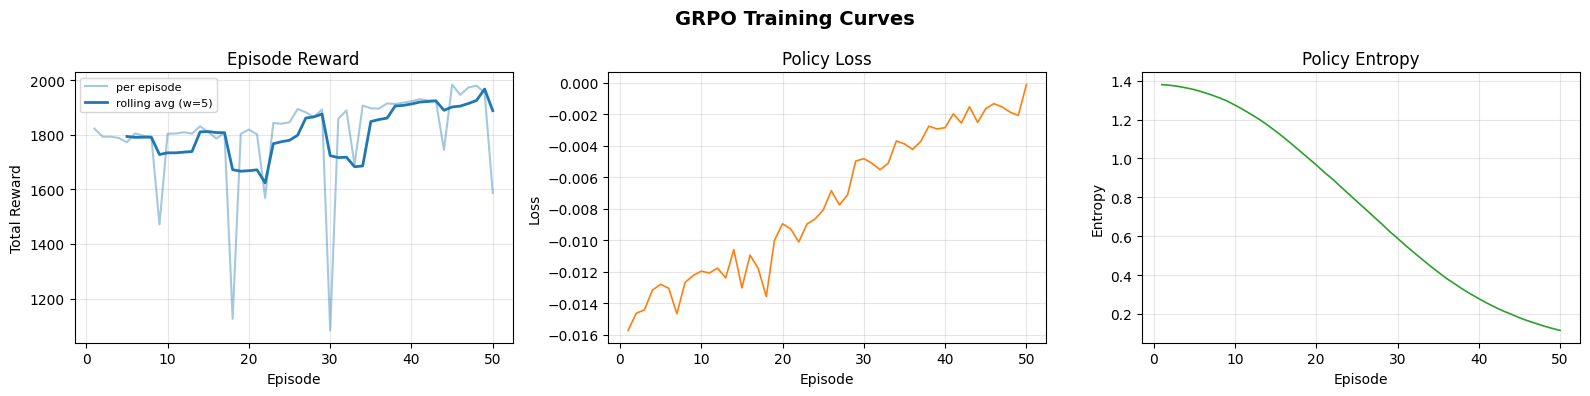

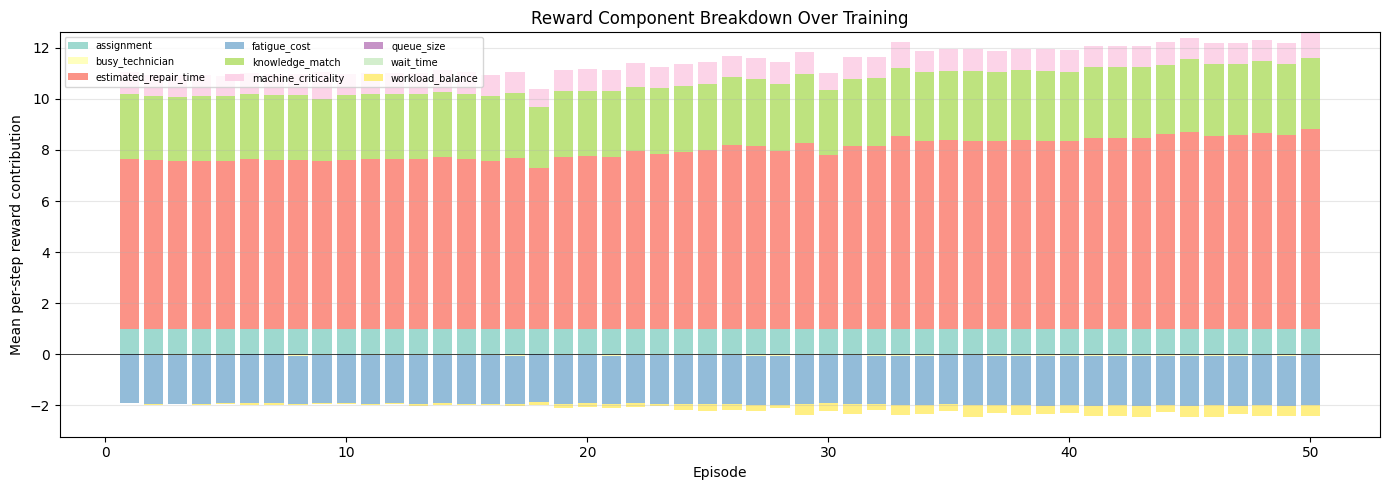

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
episodes = np.arange(1, N_EPISODES + 1)

# --- Episode reward ---
ax = axes[0]
ax.plot(episodes, episode_rewards, alpha=0.4, color="C0", label="per episode")
window = 5
if len(episode_rewards) >= window:
    rolling = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
    ax.plot(episodes[window - 1:], rolling, color="C0", linewidth=2, label=f"rolling avg (w={window})")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.set_title("Episode Reward")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Policy loss ---
ax = axes[1]
ax.plot(episodes, episode_losses, color="C1", linewidth=1.2)
ax.set_xlabel("Episode")
ax.set_ylabel("Loss")
ax.set_title("Policy Loss")
ax.grid(True, alpha=0.3)

# --- Entropy ---
ax = axes[2]
ax.plot(episodes, episode_entropies, color="C2", linewidth=1.2)
ax.set_xlabel("Episode")
ax.set_ylabel("Entropy")
ax.set_title("Policy Entropy")
ax.grid(True, alpha=0.3)

fig.suptitle("GRPO Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Reward component breakdown over training ---
component_names = sorted(episode_breakdowns[0].keys())
fig, ax = plt.subplots(figsize=(14, 5))
bottom_pos = np.zeros(N_EPISODES)
bottom_neg = np.zeros(N_EPISODES)
colors = plt.cm.Set3(np.linspace(0, 1, len(component_names)))

for i, name in enumerate(component_names):
    values = np.array([bd.get(name, 0.0) for bd in episode_breakdowns])
    pos = np.maximum(values, 0)
    neg = np.minimum(values, 0)
    ax.bar(episodes, pos, bottom=bottom_pos, width=0.8, label=name, color=colors[i], alpha=0.85)
    ax.bar(episodes, neg, bottom=bottom_neg, width=0.8, color=colors[i], alpha=0.85)
    bottom_pos += pos
    bottom_neg += neg

ax.set_xlabel("Episode")
ax.set_ylabel("Mean per-step reward contribution")
ax.set_title("Reward Component Breakdown Over Training")
ax.legend(loc="upper left", fontsize=7, ncol=3)
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 5b. Training metrics (beyond rewards)

These metrics are **independent of the reward signal** and track the actual
quality of decisions and factory outcomes:

| Metric | Type | Meaning |
|---|---|---|
| `repair_time_delta` | step | Effective - base repair time (negative = faster, good) |
| `repair_quality` | step | Knowledge match score in [0, 1] (higher = better) |
| `total_breakdowns` | episode | Count of machine breakdowns |
| `total_repairs` | episode | Count of completed repairs |
| `finished_products` | episode | Products that reached the sink |

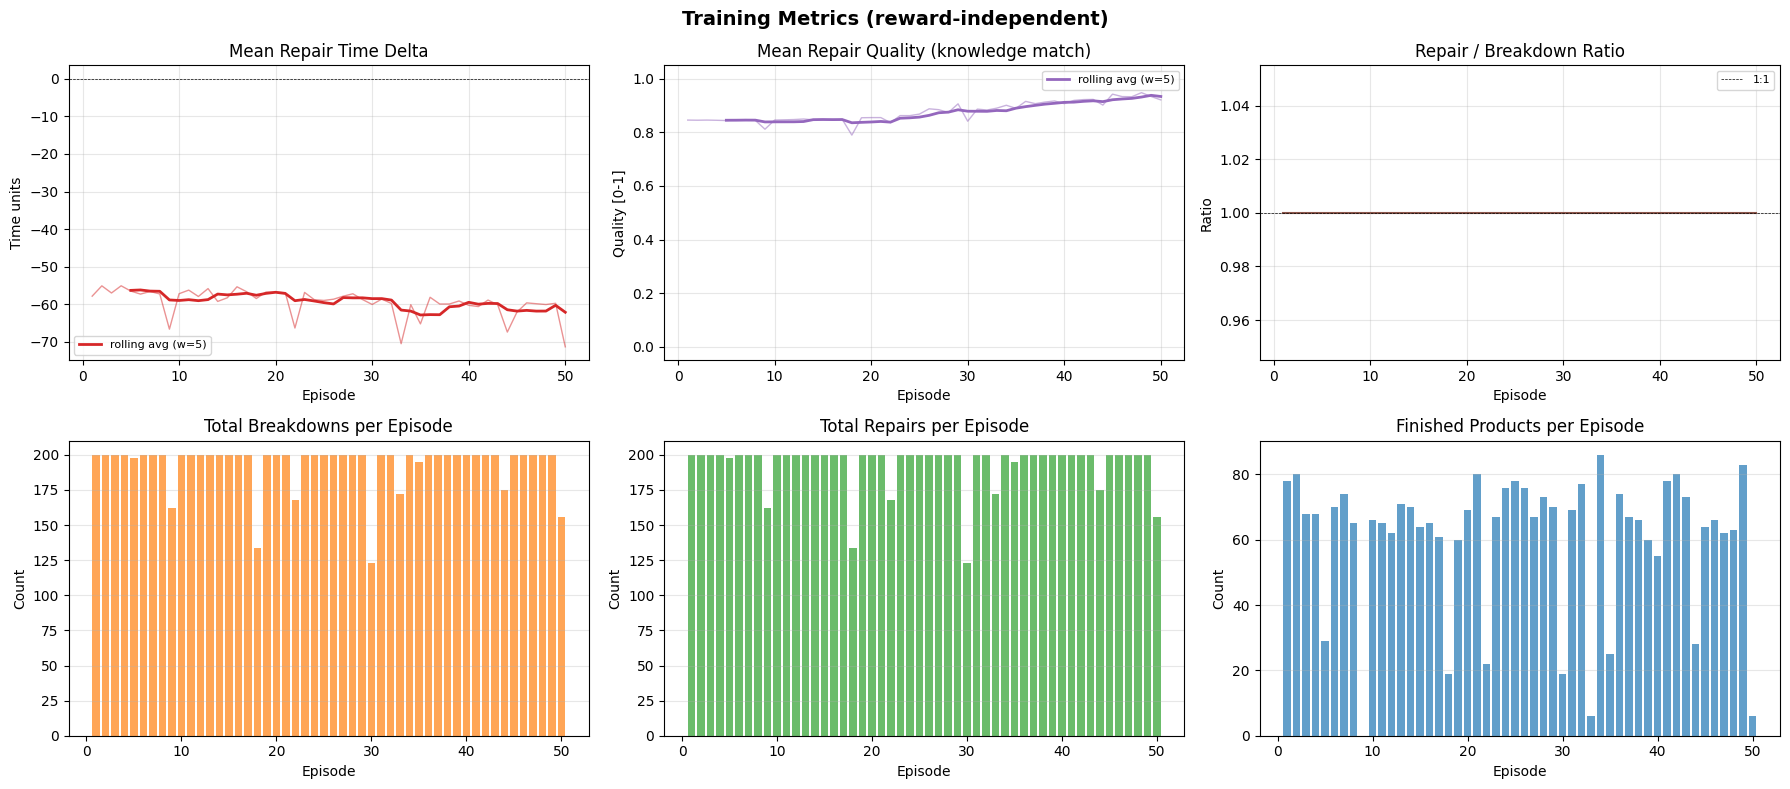

In [7]:
episodes = np.arange(1, N_EPISODES + 1)

# Extract metric time-series
repair_dt = [m.get("repair_time_delta", float("nan")) for m in episode_metrics]
repair_q = [m.get("repair_quality", float("nan")) for m in episode_metrics]
breakdowns = [m.get("total_breakdowns", 0) for m in episode_metrics]
repairs = [m.get("total_repairs", 0) for m in episode_metrics]
products = [m.get("finished_products", 0) for m in episode_metrics]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# -- Step-wise metrics --
ax = axes[0, 0]
ax.plot(episodes, repair_dt, color="C3", alpha=0.5, linewidth=1)
if len(repair_dt) >= 5:
    rolling = np.convolve(repair_dt, np.ones(5) / 5, mode="valid")
    ax.plot(episodes[4:], rolling, color="C3", linewidth=2, label="rolling avg (w=5)")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Episode")
ax.set_ylabel("Time units")
ax.set_title("Mean Repair Time Delta")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(episodes, repair_q, color="C4", alpha=0.5, linewidth=1)
if len(repair_q) >= 5:
    rolling = np.convolve(repair_q, np.ones(5) / 5, mode="valid")
    ax.plot(episodes[4:], rolling, color="C4", linewidth=2, label="rolling avg (w=5)")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Episode")
ax.set_ylabel("Quality [0-1]")
ax.set_title("Mean Repair Quality (knowledge match)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# -- Episode-wise metrics --
ax = axes[1, 0]
ax.bar(episodes, breakdowns, color="C1", alpha=0.7)
ax.set_xlabel("Episode")
ax.set_ylabel("Count")
ax.set_title("Total Breakdowns per Episode")
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1, 1]
ax.bar(episodes, repairs, color="C2", alpha=0.7)
ax.set_xlabel("Episode")
ax.set_ylabel("Count")
ax.set_title("Total Repairs per Episode")
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1, 2]
ax.bar(episodes, products, color="C0", alpha=0.7)
ax.set_xlabel("Episode")
ax.set_ylabel("Count")
ax.set_title("Finished Products per Episode")
ax.grid(True, alpha=0.3, axis="y")

# -- Repair efficiency: repairs / breakdowns --
ax = axes[0, 2]
efficiency = [r / max(b, 1) for r, b in zip(repairs, breakdowns)]
ax.plot(episodes, efficiency, color="C5", linewidth=1.5)
ax.axhline(1.0, color="black", linewidth=0.5, linestyle="--", label="1:1")
ax.set_xlabel("Episode")
ax.set_ylabel("Ratio")
ax.set_title("Repair / Breakdown Ratio")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("Training Metrics (reward-independent)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Evaluation: GRPO vs heuristic baselines

We evaluate the trained GRPO agent (deterministic mode) against heuristic
baselines over multiple seeds.  All agents are scored under the **same
rich reward function** so the comparison is fair.

In [8]:
from agents.baselines.heuristics import RandomAgent, LeastBusyAgent, LeastFatiguedAgent, ShortestQueueAgent

# We also need a structured-obs env for the heuristic baselines
struct_cfg = cfg.gym.model_copy(update={"observation_representation": "structured"})


def evaluate_agent(agent_obj, env_cfg, seeds, use_tokenizer=False):
    """Run evaluation episodes and return per-seed total rewards, breakdowns, and metrics."""
    totals = []
    all_breakdowns = []
    all_metrics = []
    for seed in seeds:
        kw = {"tokenizer": tokenizer} if use_tokenizer else {}
        with quiet():
            ev_env = KataEnv(scenario_factory=make_factory, config=env_cfg, **kw)
            obs, _ = ev_env.reset(seed=seed)

        ep_reward = 0.0
        ep_bd = defaultdict(float)
        ep_metrics = defaultdict(list)
        steps = 0
        for _ in range(env_cfg.max_episode_steps):
            action = agent_obj.select_action(obs, deterministic=True)
            with quiet():
                obs, reward, terminated, truncated, info = ev_env.step(action)
            ep_reward += reward
            steps += 1
            for k, v in info["reward_breakdown"].items():
                ep_bd[k] += v
            for k, v in info.get("metrics", {}).items():
                ep_metrics[k].append(v)
            if terminated or truncated:
                break
        totals.append(ep_reward)
        all_breakdowns.append({k: v / max(steps, 1) for k, v in ep_bd.items()})
        agg = {k: (np.mean(v) if len(v) > 1 else v[0]) for k, v in ep_metrics.items()}
        all_metrics.append(agg)
    return totals, all_breakdowns, all_metrics


eval_seeds = list(range(100, 110))

# Heuristic baselines (need structured obs)
baselines = {
    "Random": RandomAgent(n_actions),
    "LeastBusy": LeastBusyAgent(n_actions),
    "LeastFatigued": LeastFatiguedAgent(n_actions),
    "ShortestQueue": ShortestQueueAgent(n_actions),
}

eval_results = {}
eval_breakdowns = {}
eval_metrics = {}
for name, bl in baselines.items():
    eval_results[name], eval_breakdowns[name], eval_metrics[name] = evaluate_agent(bl, struct_cfg, eval_seeds)

# GRPO agent (uses token_ids obs — needs the tokenizer)
eval_results["GRPO (trained)"], eval_breakdowns["GRPO (trained)"], eval_metrics["GRPO (trained)"] = evaluate_agent(
    agent, cfg.gym, eval_seeds, use_tokenizer=True
)

print(f"{'Policy':20s} | {'Mean':>10s} | {'Std':>8s} | {'Min':>8s} | {'Max':>8s}")
print("-" * 62)
for name in eval_results:
    totals = eval_results[name]
    print(
        f"{name:20s} | {np.mean(totals):+10.2f} | {np.std(totals):8.2f} "
        f"| {min(totals):+8.2f} | {max(totals):+8.2f}"
    )

# Metrics comparison table
metric_names = ["repair_time_delta", "repair_quality", "total_breakdowns", "total_repairs", "finished_products"]
print(f"\n{'Policy':20s} | {'repair_dt':>10s} | {'quality':>8s} | {'breakdowns':>10s} | {'repairs':>8s} | {'products':>8s}")
print("-" * 82)
for name in eval_metrics:
    ms = eval_metrics[name]
    vals = {k: np.mean([m.get(k, 0) for m in ms]) for k in metric_names}
    print(
        f"{name:20s} | {vals['repair_time_delta']:+10.2f} | {vals['repair_quality']:8.3f} "
        f"| {vals['total_breakdowns']:10.1f} | {vals['total_repairs']:8.1f} | {vals['finished_products']:8.1f}"
    )

Policy               |       Mean |      Std |      Min |      Max
--------------------------------------------------------------
Random               |   +1804.80 |    10.23 | +1788.66 | +1820.69
LeastBusy            |   +1929.74 |    11.01 | +1911.98 | +1944.99
LeastFatigued        |   +1805.29 |    47.53 | +1665.82 | +1844.19
ShortestQueue        |   +1816.04 |     7.48 | +1801.05 | +1822.72
GRPO (trained)       |   +1908.06 |   306.01 |  +990.97 | +2043.58

Policy               |  repair_dt |  quality | breakdowns |  repairs | products
----------------------------------------------------------------------------------
Random               |     -56.93 |    0.845 |      200.0 |    200.0 |     71.0
LeastBusy            |     -60.17 |    0.924 |      200.0 |    200.0 |     70.6
LeastFatigued        |     -59.34 |    0.846 |      197.6 |    197.6 |     57.0
ShortestQueue        |     -57.23 |    0.848 |      200.0 |    200.0 |     66.3
GRPO (trained)       |     -62.32 |    0.959 |     

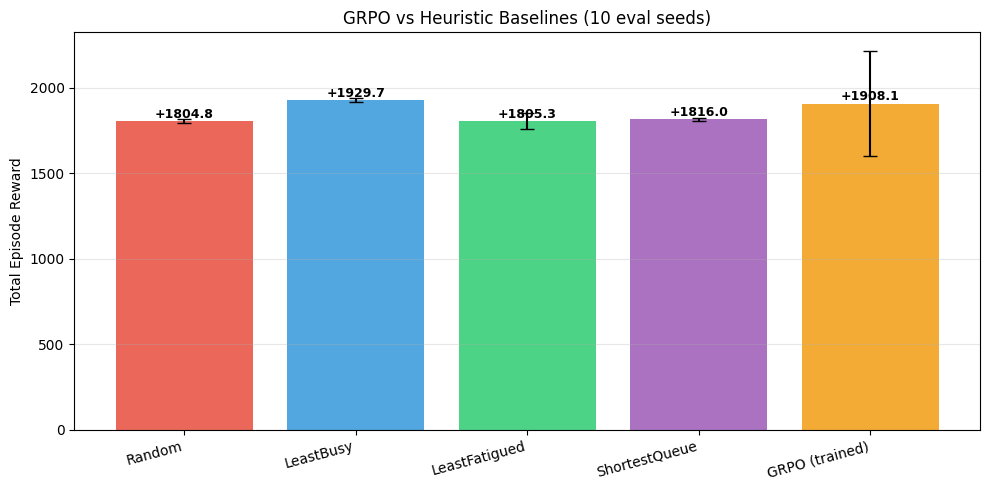

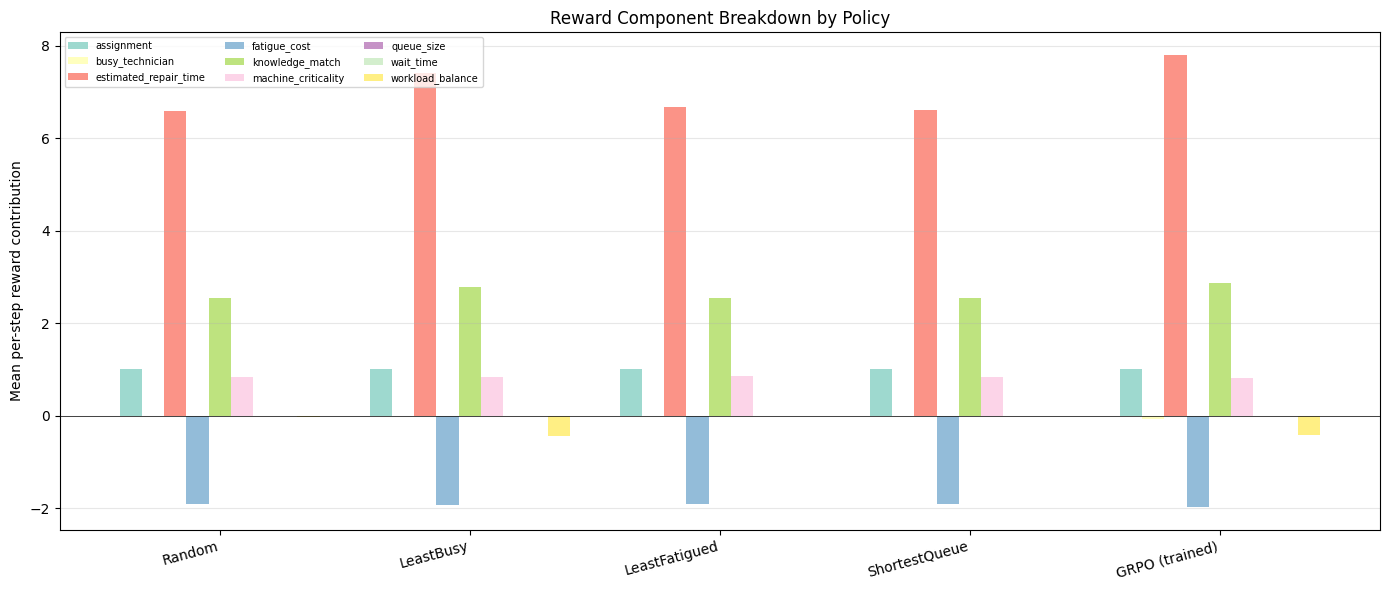

In [9]:
# --- Total reward comparison ---
fig, ax = plt.subplots(figsize=(10, 5))

names = list(eval_results.keys())
x = np.arange(len(names))
means = [np.mean(eval_results[n]) for n in names]
stds = [np.std(eval_results[n]) for n in names]
bar_colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#f39c12"]

bars = ax.bar(x, means, yerr=stds, capsize=5, color=bar_colors[:len(names)], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("Total Episode Reward")
ax.set_title("GRPO vs Heuristic Baselines (10 eval seeds)")
ax.grid(True, alpha=0.3, axis="y")

for bar, m in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
        f"{m:+.1f}", ha="center", va="bottom", fontweight="bold", fontsize=9,
    )
plt.tight_layout()
plt.show()

# --- Per-component breakdown across policies ---
all_comp_names = sorted({k for bds in eval_breakdowns.values() for bd in bds for k in bd})
policy_names = list(eval_breakdowns.keys())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(policy_names))
width = 0.8 / len(all_comp_names)
comp_colors = plt.cm.Set3(np.linspace(0, 1, len(all_comp_names)))

for i, comp in enumerate(all_comp_names):
    comp_means = [
        np.mean([bd.get(comp, 0.0) for bd in eval_breakdowns[p]])
        for p in policy_names
    ]
    ax.bar(x + i * width - 0.4 + width / 2, comp_means, width,
           label=comp, color=comp_colors[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(policy_names, rotation=15, ha="right")
ax.set_ylabel("Mean per-step reward contribution")
ax.set_title("Reward Component Breakdown by Policy")
ax.legend(fontsize=7, ncol=3, loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 7. Inspect learned policy behaviour

Run one evaluation episode step-by-step and visualize the agent's action
distribution (softmax probabilities) at each step.

In [10]:
# Collect action probabilities over one episode
with quiet():
    eval_env = KataEnv(scenario_factory=make_factory, config=cfg.gym, tokenizer=tokenizer)
    obs, _ = eval_env.reset(seed=42)

tech_names = [t.name for t in eval_env.dispatcher.techs]
action_probs_history = []
chosen_actions = []
step_rewards = []

agent.policy.eval()
for step_i in range(cfg.gym.max_episode_steps):
    token_ids = agent._extract_token_ids(obs)
    token_tensor = torch.from_numpy(token_ids).unsqueeze(0).to(agent.device)

    with torch.no_grad():
        dist = agent.policy.get_distribution(token_tensor)
        probs = dist.probs.squeeze(0).cpu().numpy()

    action_probs_history.append(probs)
    action = int(probs.argmax())
    chosen_actions.append(action)

    with quiet():
        obs, reward, terminated, truncated, info = eval_env.step(action)
    step_rewards.append(reward)

    if terminated or truncated:
        break

agent.policy.train()
action_probs_arr = np.array(action_probs_history)

print(f"Evaluation episode: {len(chosen_actions)} steps, total reward: {sum(step_rewards):+.2f}")
print(f"Action distribution (first 5 steps):")
for i in range(min(5, len(action_probs_history))):
    probs_str = ", ".join(f"{tech_names[j]}={action_probs_history[i][j]:.3f}" for j in range(n_actions))
    print(f"  step {i}: [{probs_str}] -> {tech_names[chosen_actions[i]]}")

Evaluation episode: 200 steps, total reward: +2028.83
Action distribution (first 5 steps):
  step 0: [expert=0.002, generalist=0.002, junior_1=0.984, junior_2=0.012] -> junior_1
  step 1: [expert=0.002, generalist=0.002, junior_1=0.984, junior_2=0.012] -> junior_1
  step 2: [expert=0.002, generalist=0.002, junior_1=0.984, junior_2=0.012] -> junior_1
  step 3: [expert=0.002, generalist=0.002, junior_1=0.984, junior_2=0.012] -> junior_1
  step 4: [expert=0.002, generalist=0.002, junior_1=0.984, junior_2=0.012] -> junior_1


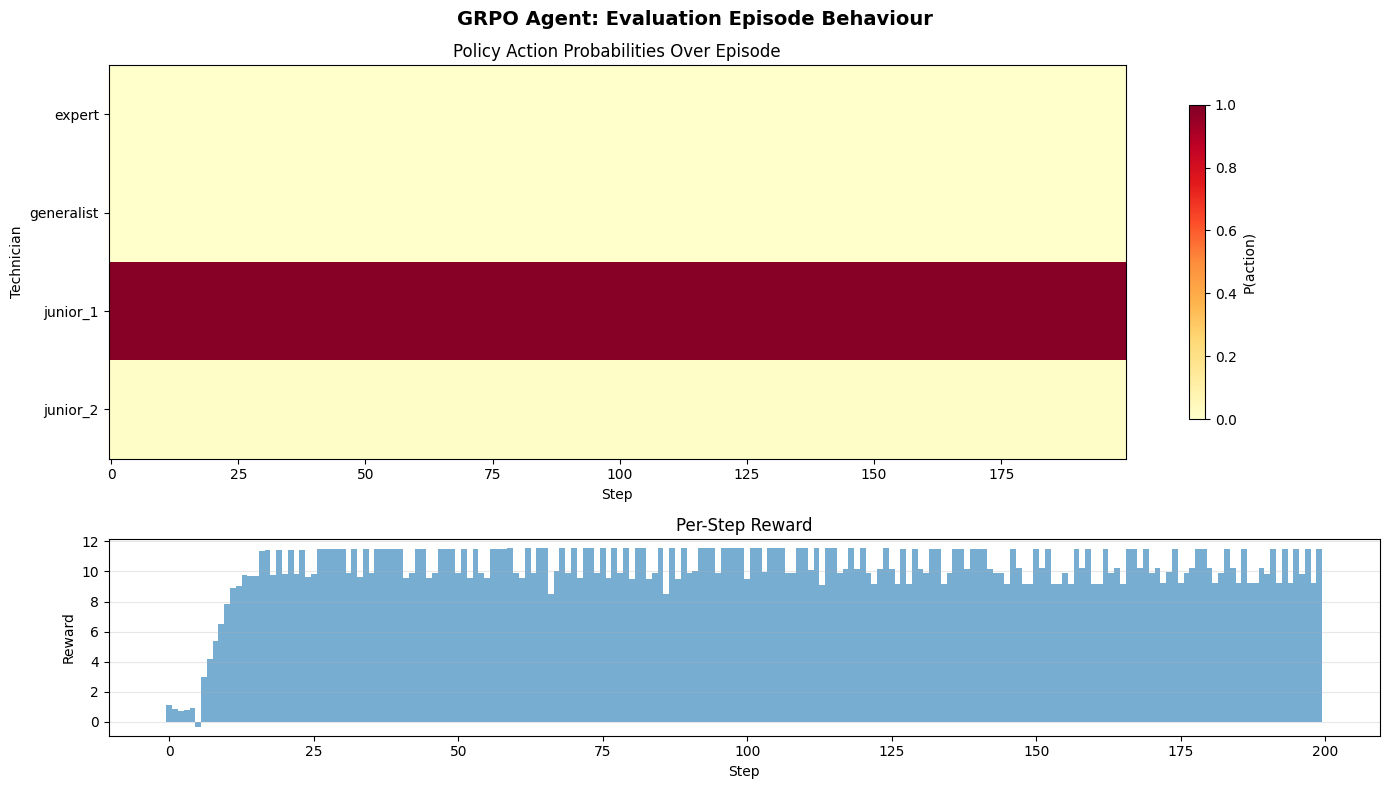

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

# --- Action probability heatmap ---
ax = axes[0]
im = ax.imshow(action_probs_arr.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_yticks(range(n_actions))
ax.set_yticklabels(tech_names)
ax.set_xlabel("Step")
ax.set_ylabel("Technician")
ax.set_title("Policy Action Probabilities Over Episode")
plt.colorbar(im, ax=ax, label="P(action)", shrink=0.8)

# --- Per-step reward ---
ax = axes[1]
ax.bar(range(len(step_rewards)), step_rewards, color="C0", alpha=0.6, width=1.0)
ax.set_xlabel("Step")
ax.set_ylabel("Reward")
ax.set_title("Per-Step Reward")
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("GRPO Agent: Evaluation Episode Behaviour", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Cumulative reward comparison

Overlay step-by-step cumulative rewards for the GRPO agent and the
least-fatigued heuristic on the same evaluation seed.

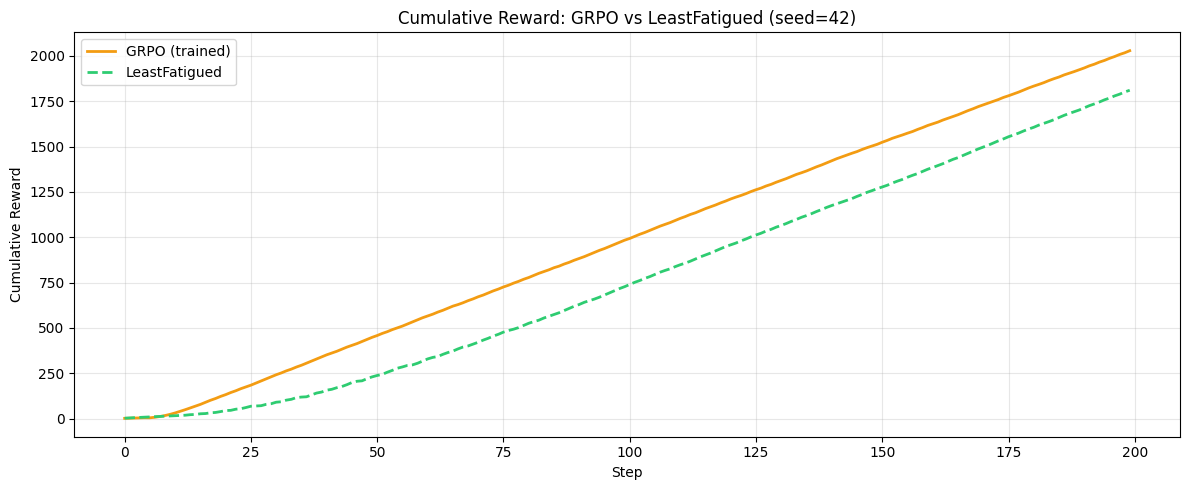

GRPO total       : +2028.83 (200 steps)
LeastFatigued    : +1810.76 (200 steps)


In [12]:
# Run LeastFatigued on the same seed for comparison
lf_agent = LeastFatiguedAgent(n_actions)
with quiet():
    lf_env = KataEnv(scenario_factory=make_factory, config=struct_cfg)
    obs_lf, _ = lf_env.reset(seed=42)

lf_rewards = []
for _ in range(struct_cfg.max_episode_steps):
    action = lf_agent.select_action(obs_lf, deterministic=True)
    with quiet():
        obs_lf, reward, terminated, truncated, _ = lf_env.step(action)
    lf_rewards.append(reward)
    if terminated or truncated:
        break

fig, ax = plt.subplots(figsize=(12, 5))

grpo_cum = np.cumsum(step_rewards)
lf_cum = np.cumsum(lf_rewards)

ax.plot(grpo_cum, label="GRPO (trained)", linewidth=2, color="#f39c12")
ax.plot(lf_cum, label="LeastFatigued", linewidth=2, color="#2ecc71", linestyle="--")
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative Reward")
ax.set_title("Cumulative Reward: GRPO vs LeastFatigued (seed=42)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GRPO total       : {grpo_cum[-1]:+.2f} ({len(step_rewards)} steps)")
print(f"LeastFatigued    : {lf_cum[-1]:+.2f} ({len(lf_rewards)} steps)")

## 9. Save the trained agent

Checkpoint the trained policy for later use or further training.

In [13]:
import os

save_dir = os.path.join(os.path.dirname(os.getcwd()), "checkpoints")
save_path = os.path.join(save_dir, "grpo_complex_factory.pt")

agent.save(save_path)
print(f"Agent saved to: {save_path}")
print(f"File size: {os.path.getsize(save_path) / 1024:.1f} KB")

Agent saved to: /Users/adrien.bolling/Library/CloudStorage/OneDrive-UniversityofLuxembourg/VSCode/knowledge-aware-technician-assignment/checkpoints/grpo_complex_factory.pt
File size: 1371.8 KB


## Notes

- **50 episodes is a minimal demo.** For meaningful learning, train for
  500+ episodes. The GRPO agent should gradually surpass heuristic baselines
  as it learns to condition on the full factory state.
- **Reward component coefficients** control how much the agent prioritises
  each objective. The values above are reasonable starting points but can be
  tuned. In particular, `knowledge_match` and `estimated_repair_time` become
  more informative once the MCA encoder is active (`use_mca_encoder=True`).
- **Group-based updates** (`sample_group_actions` + `update_from_group`) can
  be used for finer-grained GRPO by evaluating multiple candidate actions per
  state. This requires rolling back or cloning the environment, which is not
  trivial with SimPy but can be approximated with parallel environment copies.
- **Hyperparameters** like `group_size`, `clip_eps`, `entropy_coef`, and `lr`
  can be tuned for better performance. The entropy coefficient is important
  to prevent premature convergence to a deterministic policy.